## Installing Dependencies

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [34]:
from langchain_huggingface import HuggingFaceEmbeddings
from sentence_transformers import SentenceTransformer
from langchain_core.documents import Document 

embedding_model = HuggingFaceEmbeddings(model_name ="sentence-transformers/all-MiniLM-L6-v2" )

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9591.56it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [35]:
from langchain_huggingface import HuggingFaceEndpoint,ChatHuggingFace
ll = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.3-70B-Instruct",
    task="text-generation",

)
model1 = ChatHuggingFace(llm=ll,temperature = 0)
result = model1.invoke("hello?")
print(result.content)

Hello. It's nice to meet you. Is there something I can help you with, or would you like to chat?


## PDF-Retrieval chain

In [36]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS

In [37]:
loader = PyPDFLoader("C:/Users/venne/Music/Documents/CRAG/data/DistilBert.pdf")
docs = loader.load()
print(len(docs))

splitter = RecursiveCharacterTextSplitter(
    chunk_size = 500,
    chunk_overlap = 50
)

chunks = splitter.split_documents(docs)
print(len(chunks))

5
43


In [38]:
vector_store = FAISS.from_documents(chunks, embedding_model)

In [39]:
vector_store.index_to_docstore_id

{0: '89c6d08b-846f-44ab-b907-6dd02ffbbe03',
 1: '68c0f989-6acf-40d3-a67e-927131699ffa',
 2: '8b76302e-eaf9-4ab1-84be-7db1047a5f64',
 3: '8ae10ec6-3ae2-44ef-b2c8-61095f24488d',
 4: 'e85b824a-f083-4369-9cc0-2c1924c76b20',
 5: '254fcbb9-ea45-4d49-bdfe-d6276a16ddd7',
 6: 'a6bc6da4-a112-447c-948d-ec721b9966c7',
 7: 'c30b9bac-3f4d-4498-9065-526f8d7114ed',
 8: 'ff53d6a4-5576-42cb-9f84-da2f5000c7d6',
 9: '0099da6f-214a-4fdc-9159-838015c41f97',
 10: 'eb78d6bd-2679-4caa-8df6-ce7901c679ba',
 11: 'ad86dda1-3aa8-4014-b9f1-acdcc0d76bb4',
 12: 'f5e6b01f-1f6c-4692-874d-d87e7fed1a55',
 13: '09d9c474-bd2e-4d7a-873a-04679c27f4d2',
 14: '1a303d83-b856-4e9b-b42b-d5307465d0bf',
 15: '54567e57-cfef-4daa-9c93-045f3c4e0813',
 16: '8ed3d447-d6ee-411c-b6ec-fd14d857677e',
 17: 'b4206f13-f86e-4d5b-8b1c-6b7b34fb7f79',
 18: 'b08b1bee-4c1d-4426-9ff1-7f5fbe56a608',
 19: 'dadb00d3-9514-499d-b34b-b7c706bd4697',
 20: '871fe016-1497-407b-8c71-a33e18a8bca4',
 21: 'dab121b1-c32f-4538-a675-b55ad358ac12',
 22: '7b8aae56-a70f-

In [40]:
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 2})

In [41]:
question = "what is difference between distil bert and bert ?"

In [42]:
docs = retriever.invoke(question)
print(docs)

[Document(id='8ed3d447-d6ee-411c-b6ec-fd14d857677e', metadata={'producer': 'pdfTeX-1.40.17', 'creator': 'LaTeX with hyperref package', 'creationdate': '2020-03-03T01:35:16+00:00', 'author': '', 'keywords': '', 'moddate': '2020-03-03T01:35:16+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.14159265-2.6-1.40.17 (TeX Live 2016) kpathsea version 6.2.2', 'subject': '', 'title': '', 'trapped': '/False', 'source': 'C:/Users/venne/Music/Documents/CRAG/data/DistilBert.pdf', 'total_pages': 5, 'page': 2, 'page_label': '3'}, page_content='Table 1: DistilBERT retains 97% of BERT performance. Comparison on the dev sets of the\nGLUE benchmark. ELMo results as reported by the authors. BERT and DistilBERT results are the\nmedians of 5 runs with different seeds.\nModel Score CoLA MNLI MRPC QNLI QQP RTE SST-2 STS-B WNLI\nELMo 68.7 44.1 68.6 76.6 71.1 86.2 53.4 91.5 70.4 56.3\nBERT-base 79.5 56.3 86.7 88.6 91.8 89.6 69.3 92.7 89.0 53.5\nDistilBERT 77.0 51.3 82.2 87.5 89.2 88.5 59.9 91.3 86.9 56.3\nT

## Relevance Evaluation of Retrieved Documents

In [43]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser


system_prompt = """
You are a grader assessing whether a retrieved document is relevant to a user question.
If the document has content that matches or semantically relates to the question, say "yes".
If not, say "no".
Reply with only "yes" or "no" — nothing else.
"""

grade_prompt = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    ("human", "Retrieved document:\n\n{document}\n\nUser question: {question}"),
])

retrieval_grader_chain = grade_prompt | model1 | StrOutputParser()

output = retrieval_grader_chain.invoke({"document": docs, "question": question})
print(output)


yes


## Answer Generation Chain

In [44]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

rag_prompt = ChatPromptTemplate.from_messages([
    ("system", (
        "You are an assistant for question-answering tasks. "
        "Use the following pieces of retrieved context to answer the question. "
        "If you don't know the answer, just say that you don't know. "
        "Use three sentences maximum and keep the answer concise."
    )),
    ("human", "Question: {question}\n\nContext: {context}\n\nAnswer:"),
])

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

rag_chain = rag_prompt | model1 | StrOutputParser()


In [45]:
generation = rag_chain.invoke({"context": format_docs(docs), "question": question})
print(generation)

DistilBERT is a smaller and faster version of BERT, retaining 97% of its language understanding capabilities. It is 40% smaller and 60% faster than BERT, making it suitable for edge applications. The main difference between the two is the size and speed, with DistilBERT being a more compact and efficient model.


## Question Re-write

In [46]:

system = """
 You are a question re-writer that converts an input question to a better version that is optimized
for web search. Look at the input and try to reason about the underlying semantic intent / meaning.
Just give only rewritten question Dont give anything explanation.

"""

re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system",system),
        ("human","Here is the initial question :\n\n {question} \n Formulate an improved question.",),

    ]
)

question_rewriter = re_write_prompt | model1 | StrOutputParser()

In [47]:
# Run chain and output results
print(f'[Original question]: "{question}"')
print("[Query-rewrite]:", question_rewriter.invoke({"question": question}))

[Original question]: "what is difference between distil bert and bert ?"
[Query-rewrite]: What are the key differences between DistilBERT and BERT in terms of architecture, performance, and applications?


## Web Search Tool

In [48]:
from langchain_tavily import TavilySearch
web_search_tool = TavilySearch(max_results = 2)

In [49]:
# Execute web search tool
results = web_search_tool.invoke({"query": question})
print(results)

{'query': 'what is difference between distil bert and bert ?', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://www.reddit.com/r/learnmachinelearning/comments/11gepxq/bertmodel_vs_distilbertmodel_from_hugginface', 'title': 'BertModel vs DistilBertModel from HugginFace (Pytorch) - Reddit', 'content': 'DistilBertModel is a smaller and faster version of BertModel. It has fewer layers and smaller hidden dimensions compared to BertModel, which allows it to be', 'score': 0.85157084, 'raw_content': None}, {'url': 'https://www.geeksforgeeks.org/nlp/distilbert-in-natural-language-processing', 'title': 'DistilBERT in Natural Language Processing - GeeksforGeeks', 'content': '# DistilBERT in Natural Language Processing. ****DistilBERT**** is a distilled version of BERT meaning it is trained using ****knowledge distillation**** a technique where a smaller model (student) learns from a larger model (teacher). It retains 97% of BERT’s performance while being 40%

## State


In [50]:
from typing import Annotated , List , TypedDict

class AgentState(TypedDict):
  question : Annotated[str," The question to answer"]
  generation : Annotated[str , "The generation from the llm"]
  web_search : Annotated[str , "Whether to add search"] # yes or no
  documents : Annotated [ List[str] , " The documents received "]

## Node

In [51]:
from langchain_core.documents import Document

def retrieve( state : AgentState) -> AgentState:
  question = state["question"]
  documents = retriever.invoke(question)
  return {"documents" : documents}


def generate(state : AgentState) -> AgentState:
  question = state["question"]
  documents = state["documents"]
  generation = rag_chain.invoke({"context" : documents ,"question" : question })
  return {"generation" : generation}


def grade_documents(state: AgentState)->AgentState:
    question = state["question"]
    documents = state["documents"]

    filtered_docs = []
    relevant_doc_count = 0

    print("\n--- Retrieved Documents & Grading ---")
    for i, d in enumerate(documents, 1):
        score = retrieval_grader_chain.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = "RELEVANT" if score == "yes" else "NOT RELEVANT"
        print(f"\nDocument {i}:")
        print(d.page_content)
        print(f"Grade: {grade}")

        if score == "yes":
            filtered_docs.append(d)
            relevant_doc_count += 1

    print("-------------------------------------\n")
    web_search = "Yes" if relevant_doc_count == 0 else "No"
    return {"documents": filtered_docs, "web_search": web_search}

def query_rewrite(state : AgentState) -> AgentState:
  question = state["question"]
  better_question = question_rewriter.invoke({"question" : question})
  print(f"\n--- Rewritten Query ---\n{better_question}\n-----------------------\n")
  return {"question": better_question}

def web_search(state: AgentState) -> AgentState:
    question = state["question"]
    documents = state["documents"]

    docs = web_search_tool.invoke(question)

    if isinstance(docs, str):
        content = docs
    elif isinstance(docs, list):
        content = "\n".join(d["content"] if isinstance(d, dict) else str(d) for d in docs)
    else:
        content = str(docs)  

    print(f"\n--- Web Search Results ---\n{content}\n--------------------------\n")
    web_results = Document(page_content=content)
    documents.append(web_results)

    return {"documents": documents}

## Function for conditional edges

In [52]:
def decide_to_generate(state:AgentState) -> AgentState:
  web_search = state["web_search"]

  if web_search == "Yes" :
    return "query_rewrite"

  else:
    return "generate"

## Graph Creation

In [53]:
from langgraph.graph import END,StateGraph , START

graph = StateGraph(AgentState)
graph.add_node("retrieve" , retrieve)
graph.add_node("grade_documents",grade_documents)
graph.add_node("generate" , generate)
graph.add_node("query_rewrite" , query_rewrite)
graph.add_node("web_search_node" ,web_search)

graph.add_edge(START , "retrieve")
graph.add_edge("retrieve" , "grade_documents")

graph.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "query_rewrite" : "query_rewrite",
        "generate"  : "generate",
    },
)

graph.add_edge("query_rewrite","web_search_node")
graph.add_edge("web_search_node","generate")
graph.add_edge("generate" , END)

app = graph.compile()

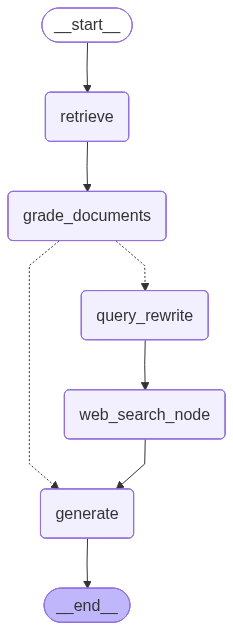

In [54]:
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

## Graph Execution


In [55]:
input = {
    "question": "What is Markov Assumption in N-grams?",
}

final_generation = ""
for output in app.stream(input):
    for key, value in output.items():
        if "generation" in value:
            final_generation = value["generation"]

print("\nFinal Answer")
print(final_generation)


--- Retrieved Documents & Grading ---

Document 1:
maximizing the estimated probability of gold labels. A standard training objective thus involves
minimizing the cross-entropy between the model’s predicted distribution and the one-hot empirical
distribution of training labels. A model performing well on the training set will predict an output
distribution with high probability on the correct class and with near-zero probabilities on other
classes. But some of these "near-zero" probabilities are larger than others and reﬂect, in part, the
Grade: NOT RELEVANT

Document 2:
Data and compute power We train DistilBERT on the same corpus as the original BERT model:
a concatenation of English Wikipedia and Toronto Book Corpus [Zhu et al., 2015]. DistilBERT
was trained on 8 16GB V100 GPUs for approximately 90 hours. For the sake of comparison, the
RoBERTa model [Liu et al., 2019] required 1 day of training on 1024 32GB V100.
4 Experiments
General Language Understanding We assess the language 

In [56]:
input = {
    "question": "What are residual layers?",
}

final_generation = ""
for output in app.stream(input):
    for key, value in output.items():
        if "generation" in value:
            final_generation = value["generation"]

print("\n Final Answer")
print(final_generation)



--- Retrieved Documents & Grading ---

Document 1:
layer and layer normalisation) are highly optimized in modern linear algebra frameworks and our
investigations showed that variations on the last dimension of the tensor (hidden size dimension) have
a smaller impact on computation efﬁciency (for a ﬁxed parameters budget) than variations on other
factors like the number of layers. Thus we focus on reducing the number of layers.
Student initialization In addition to the previously described optimization and architectural choices,
Grade: NOT RELEVANT

Document 2:
an important element in our training procedure is to ﬁnd the right initialization for the sub-network to
converge. Taking advantage of the common dimensionality between teacher and student networks,
we initialize the student from the teacher by taking one layer out of two.
2https://github.com/huggingface/transformers
3E.g. BERT-base’s predictions for a masked token in " I think this is the beginning of a
Grade: NOT RELEVANT
----